In [1]:
import h5py
import numpy as np
from pathlib import Path
from package.texture_tomography.operators.pfo_single_material import PFO_SINGLE, estimate_L_power
import yaml
from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_huber_opencl import FISTAHuberOpenCL
from package.texture_tomography.gpu_live_tracker import GPUMemoryLogger
import pyopencl.array as clarray
from package.texture_tomography.multiresolution_refiner import OrientationTree
from package.texture_tomography.material import Material
import matplotlib.pyplot as plt
from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d
from scipy.spatial.transform import Rotation as R
from sklearn.neighbors import KDTree
import hdf5plugin


INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
pruned_orient = np.load('/work3/msaca/basis_3/numpy_matrix_flat_thin_2mrad.npy')

sigma = 0.007
grid = OrientationTree.from_rotation_matrices(pruned_orient.transpose((0,2,1)), sigma=sigma)
grid_sp = R.concatenate(grid.rotations_at_level(0))

In [3]:
with h5py.File('/work3/msaca/textomo_run_017/reconstruction.h5', "r") as f:
    print(list(f.keys()))  # list datasets/groups at root level
    
    coeffs = f["x"][:]   # load dataset into NumPy array
    print(coeffs.shape)

['orientations', 'x']
(148, 148, 37599)


/tmp/pbs.622432.hnode41/ipykernel_894608/1072369744.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


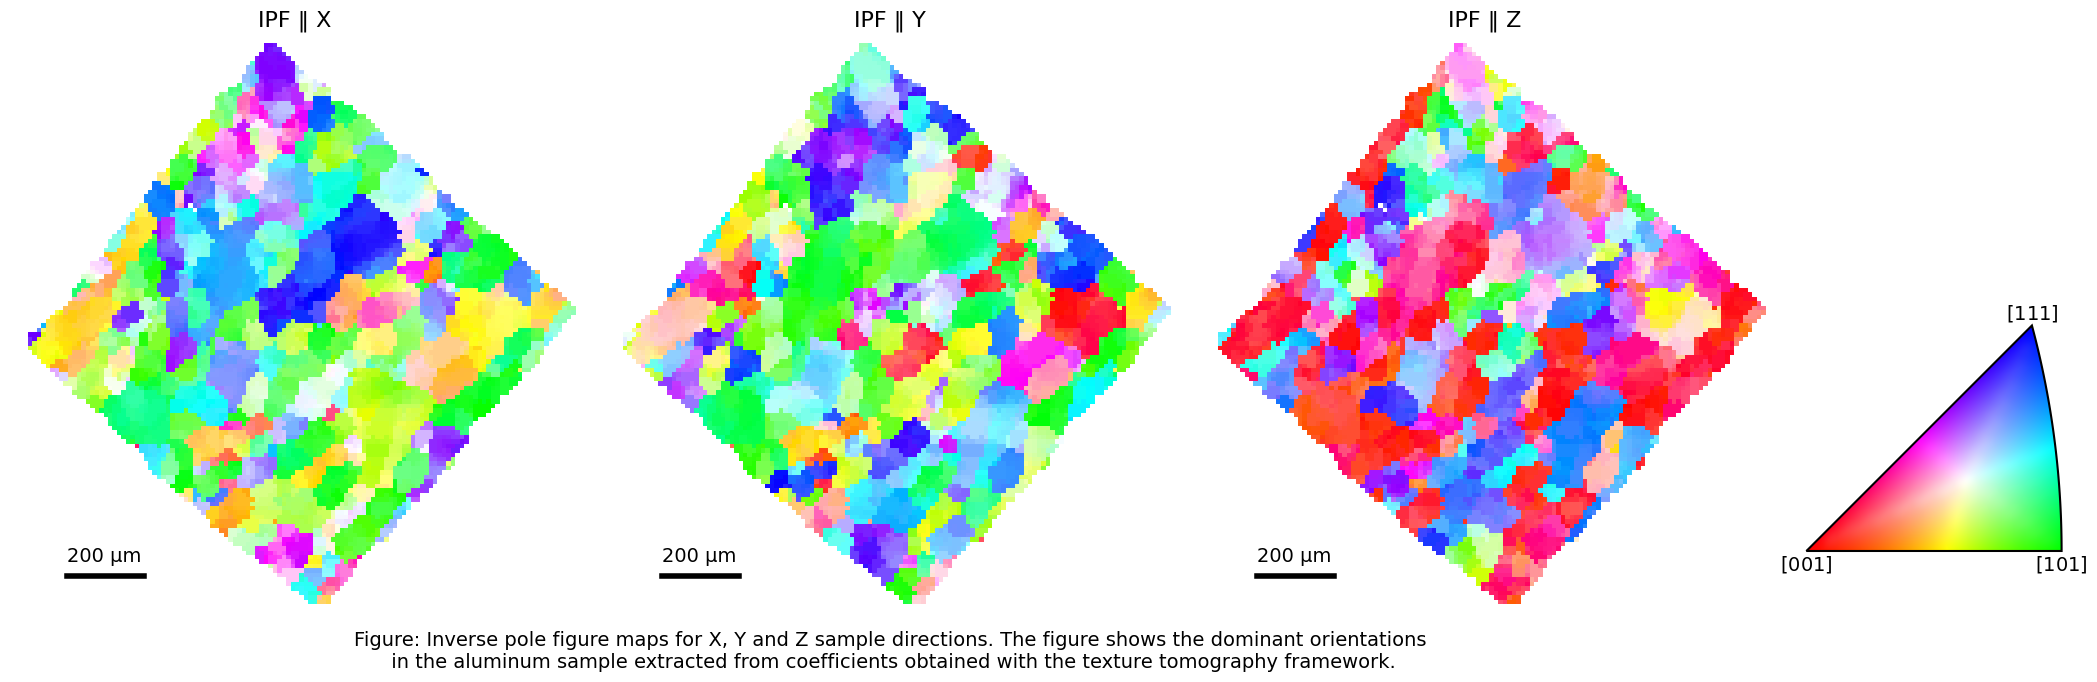

In [4]:
stepsize = 0.004
extent = (0, coeffs.shape[0]*stepsize,
          coeffs.shape[1]*stepsize, 0)

# mask (computed once)
mask = coeffs.sum(axis=2) > 0.003
mask[:7] = mask[-7:] = False
mask[:, :7] = mask[:, -7:] = False

# scale bar params
px_um, npx = 10, 20
L = npx * stepsize
x0 = 0.1 * coeffs.shape[0] * stepsize
y0 = 0.95 * coeffs.shape[1] * stepsize

directions = [[1,0,0], [0,1,0], [0,0,1]]
titles = ["IPF ‖ X", "IPF ‖ Y", "IPF ‖ Z"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="white")

for i, (ax, direction, title) in enumerate(zip(axes, directions, titles)):

    ipfkey = plot.IPFColorKeyTSL(
        symmetry.Oh,
        direction=Vector3d(direction)
    )

    orientations = Orientation.from_scipy_rotation(grid_sp)
    orientations.symmetry = ipfkey.symmetry

    rgb = ipfkey.orientation2color(orientations)[
        np.argmax(coeffs, axis=-1)
    ]
    rgb[~mask] = 1.0

    ax.imshow(rgb[-10:10:-1, -10:10:-1], extent=extent)
    ax.axis("off")
    ax.set_title(title, fontsize=16)

    # scale bar
    ax.plot([x0, x0 + L], [y0, y0], lw=4, color='black')
    ax.text(
        x0, y0 - 0.05 * coeffs.shape[1] * stepsize,
        f"{npx * px_um} µm",
        color='black', ha='left', va='top', fontsize=14
    )

    # ---- show IPF color key only on last subplot ----
    if i == 2:
        bbox = ax.get_position()
        ax_ckey = fig.add_axes(
            [bbox.x1 - 0.02, bbox.y0 - 0.05, 0.4, 0.4],
            projection="ipf",
            symmetry=orientations.symmetry,
            zorder=2
        )
        ax_ckey.plot_ipf_color_key(show_title=False)
        ax_ckey.patch.set_facecolor("None")


# figure-wide text
fig.text(
    0.5, -0.02,
    "Figure: Inverse pole figure maps for X, Y and Z sample directions. The figure shows the dominant orientations\n in the aluminum sample extracted from coefficients obtained with the texture tomography framework.",
    ha="center",
    va="top",
    fontsize=14
)

plt.tight_layout()
#plt.savefig("/work3/msaca/ipf_xyz_combined.png", dpi=600, bbox_inches="tight")
plt.show()


In [31]:
cif_path = '/dtu-compute/msaca/cif_collections/amphibolite/cif_all'
wavelength_kev = 35.0
min_two_theta = 0
max_two_theta = 30/180*np.pi
reflection_cutoff = 0.01

cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)

materials = []

for i_mat in range(N_mat):
    path = cif_folder / filenames[i_mat]
    print(filenames[i_mat])
    material = Material.from_cif(
        cif_path=path,
        wavelength_kev=wavelength_kev,
        min_two_theta=min_two_theta,
        max_two_theta=max_two_theta,
        intensity_cutoff_fraction=reflection_cutoff,
    )
    materials.append(material)

Anorthite__0000370.cif
Hornblende_1249.cif
Anorthite__0000371.cif
Tremolite_368.cif
Hornblende_5449.cif
180326_Na(AlSi3O8)_alb.cif


In [32]:
materials[0].reflections

array([([  0,   0,   1], 2, 12.74425371, 0.02779605,   1.01586552),
       ([  1,   1,  -1], 2,  6.82204172, 0.05192996,   6.99403975),
       ([  1,  -1,   0], 2,  6.52860207, 0.05426461,   9.3615675 ),
       ([  0,   2,   0], 2,  6.43250667, 0.05507547,   1.62887397),
       ([  1,   2,  -1], 2,  5.01304002, 0.07067614,   2.01918752),
       ([  0,   2,  -2], 2,  4.68788886, 0.07558048,  16.8762995 ),
       ([  1,   2,  -2], 2,  4.59785714, 0.07706117,   1.38185164),
       ([  0,   0,   3], 2,  4.24808457, 0.08340966,   1.60174773),
       ([  2,   0,  -2], 2,  4.04684606, 0.08755998,  53.63880777),
       ([  0,   1,   3], 2,  3.95517738, 0.08959069,   1.00303353),
       ([  1,  -1,   2], 2,  3.9201663 , 0.09039137,  12.20752121),
       ([  1,   2,  -3], 2,  3.85965298, 0.09180955,   1.17421094),
       ([  1,  -3,   0], 2,  3.78526095, 0.0936152 ,  29.41840088),
       ([  1,   3,  -1], 2,  3.77475321, 0.09387599,   2.90350375),
       ([  1,   1,   2], 2,  3.76971774, 0.09400

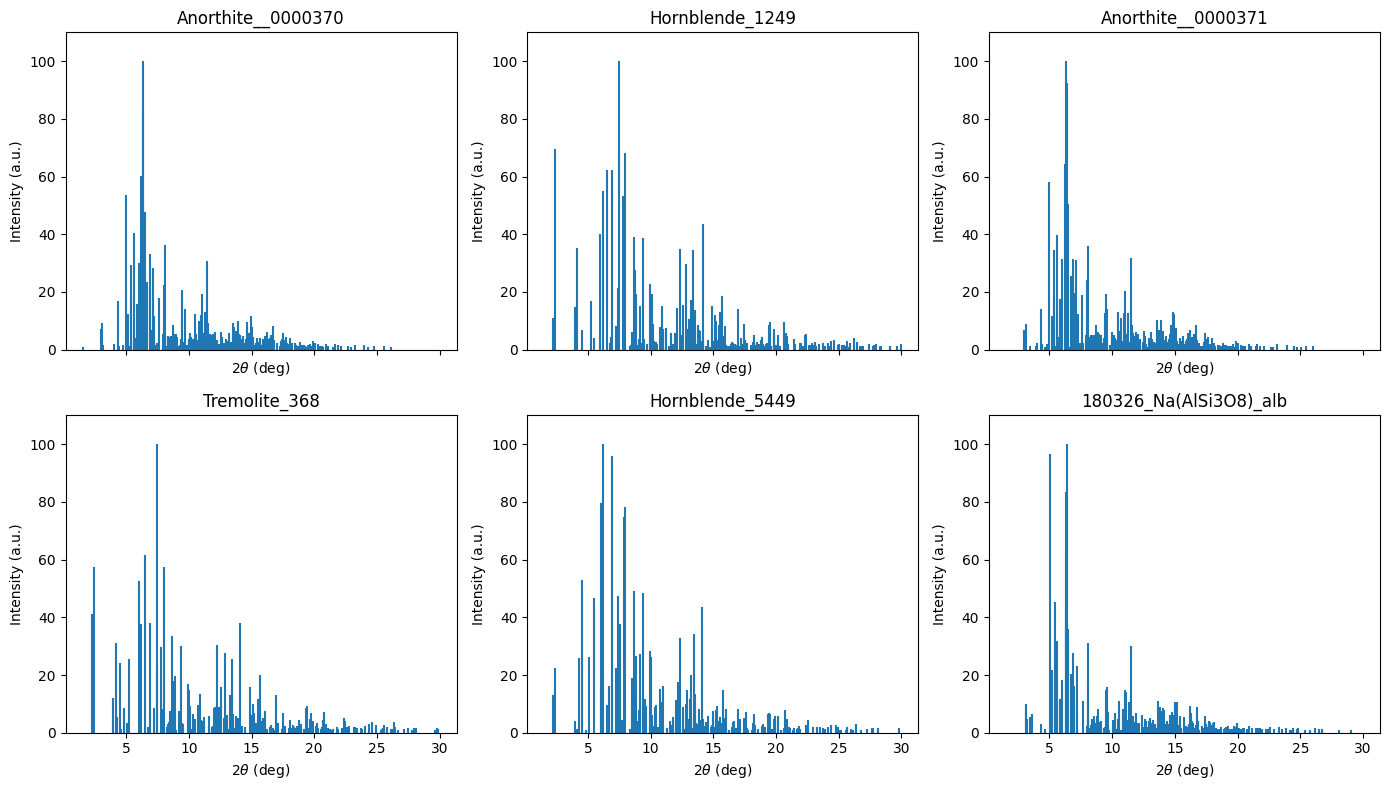

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plot_six_materials(materials, normalize=True):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=False)
    axes = axes.ravel()

    for i in range(6):
        mat = materials[i]
        ax = axes[i]

        refl = mat.reflections
        tth = np.degrees(refl["two_theta"].astype(float))
        I = refl["intensity"].astype(float)

        # sort by angle
        order = np.argsort(tth)
        tth = tth[order]
        I = I[order]

        if normalize and I.size:
            I = I / I.max() * 100.0

        ax.vlines(tth, 0.0, I)
        ax.set_title(mat.name)
        ax.set_xlabel(r"2$\theta$ (deg)")
        ax.set_ylabel("Intensity (a.u.)")

        if I.size:
            ax.set_ylim(0, I.max() * 1.1)

    plt.tight_layout()
    plt.show()

plot_six_materials(materials)

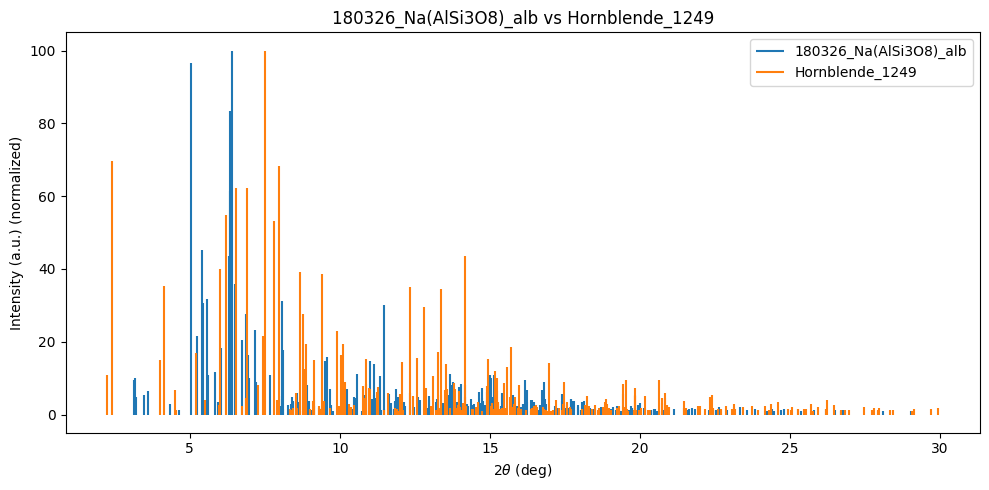

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def plot_two_materials(materials, idx1, idx2, normalize=True):
    m1 = materials[idx1]
    m2 = materials[idx2]

    fig, ax = plt.subplots(figsize=(10, 5))

    for mat, color in zip([m1, m2], ["tab:blue", "tab:orange"]):
        refl = mat.reflections
        tth = np.degrees(refl["two_theta"].astype(float))
        I = refl["intensity"].astype(float)

        order = np.argsort(tth)
        tth = tth[order]
        I = I[order]

        if normalize and I.size:
            I = I / I.max() * 100.0

        ax.vlines(tth, 0.0, I, colors=color, label=mat.name)

    ax.set_xlabel(r"2$\theta$ (deg)")
    ax.set_ylabel("Intensity (a.u.)" + (" (normalized)" if normalize else ""))
    ax.legend()
    ax.set_title(f"{m1.name} vs {m2.name}")

    plt.tight_layout()
    plt.show()

plot_two_materials(materials, 5, 1)

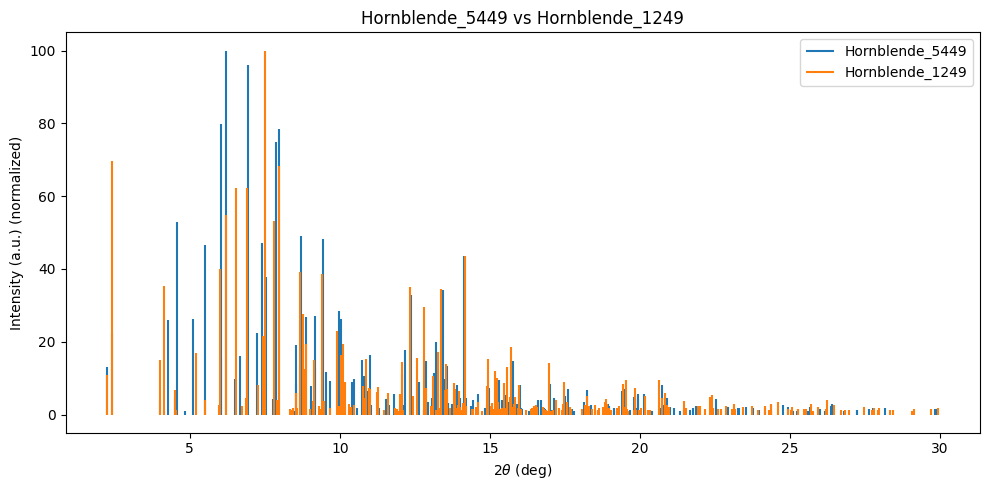

In [35]:
plot_two_materials(materials, 4, 1)

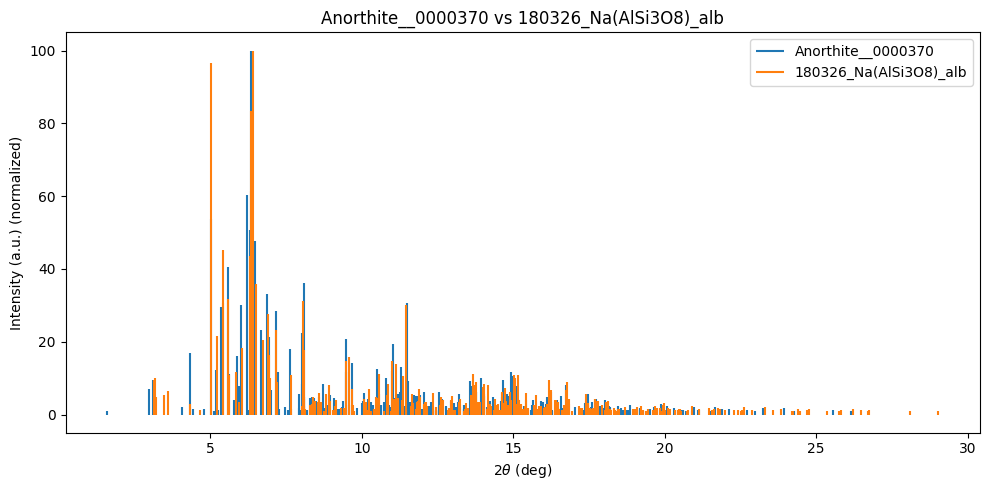

In [36]:
plot_two_materials(materials, 0, 5)

In [1]:
import h5py, hdf5plugin
import yaml
import matplotlib.pyplot as plt

In [2]:
with open('texture_tomography/configs/bb_config_1.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

poni_path = cfg['poni_path']
datapath = cfg['datapath']
diffraction_file = cfg['diffraction_file']
Nx = cfg['Nx']
N_rot = cfg['N_rot']
N_chi = cfg['N_chi']
N_theta = cfg['N_theta']
output_file = cfg["integrated_file"]

In [3]:
with h5py.File(datapath + diffraction_file, 'r') as f:

    for i_N_rot in range(N_rot):

        dataset = f['entry/instrument/pilatus/data']
        data = dataset[30200]

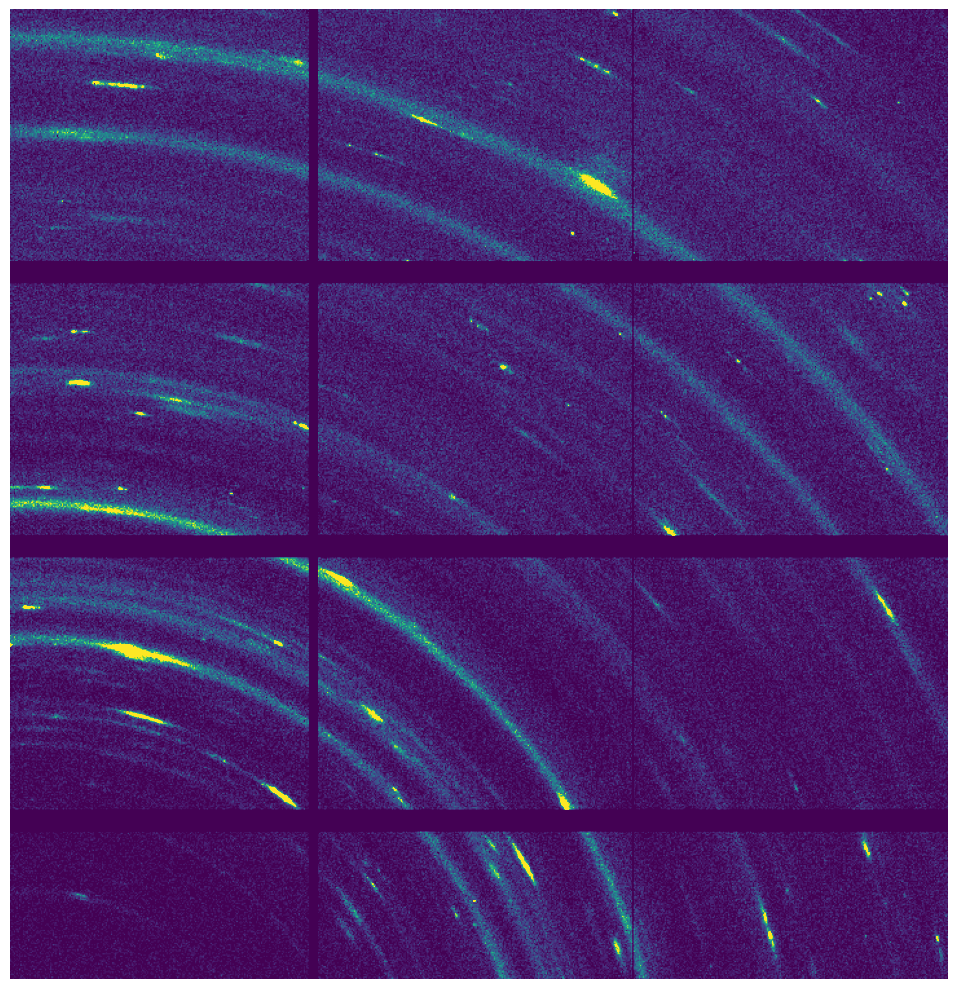

In [9]:
plt.figure(figsize=(10,10))
plt.imshow(data[:750:,750:])
plt.axis('off')
plt.clim([0,20])
plt.tight_layout()
plt.savefig('btp_plot.png',dpi=100)
